# 3-Class EEG Movement Classifier
## `NoMovement` · `Flexing` · `Extending`

---

### What this notebook does
Reads EEG recordings collected with `experiment_calibration.py`, extracts 30 features
from each trial, and trains an **XGBoost** classifier to distinguish three states of the arm.

The trained model is saved to `models/` and loaded by `live_3class_detector.py` for real-time inference.

---

### Feature vector (30 total per trial)

| # | Group | What it captures |
|---|-------|-----------------|
| 0–20 | Bandpower (7 ch × 3 bands) | Spectral energy in mu (8–13 Hz), beta (13–30 Hz), low-gamma (30–50 Hz) at F3/F4/C3/Cz/C4/P3/P4 |
| 21–22 | C3–C4 lateralisation | Left-vs-right motor asymmetry during movement |
| 23–24 | Motor / frontal ratio | How much C3 activity relative to frontal baseline |
| 25–27 | Time-domain std (C3, Cz, C4) | Raw signal amplitude variation at motor sites |
| 28 | ERD_dB | mu+beta power change: first 1 s vs last 2 s of epoch — negative = arm moved |
| 29 | cycle_pos / 3.0 | Position in the repeating 4-trial block (0–3, normalised) |

> **cycle_pos note:** With all 3 classes trained (incl. NoMovement), cycle_pos is informative
> but NOT deterministic — the live detector also adds an ERD gate so movement is verified
> physiologically before ML runs.

---

### Output files saved to `models/`
| File | Contents |
|------|----------|
| `xgb_3class_model.pkl` | Trained XGBoost classifier |
| `3class_scaler.pkl` | StandardScaler (fit on training data) |
| `3class_label_encoder.pkl` | LabelEncoder (Extending=0, Flexing=1, NoMovement=2) |
| `3class_metadata.json` | All parameters, accuracy results, feature names |

In [9]:
# ── Install dependencies ───────────────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'numpy', 'pandas', 'scipy', 'scikit-learn', 'xgboost',
    'matplotlib', 'seaborn', '-q'])
print('Packages ready.')

Packages ready.


In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os, json, pickle, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

try:
    from numpy import trapezoid as _trapz
except ImportError:
    from numpy import trapz as _trapz

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import xgboost as xgb

np.random.seed(42)
print(f'XGBoost {xgb.__version__}  —  imports OK')

XGBoost 3.2.0  —  imports OK


## Step 1 — Configuration
Set your data path and all signal-processing / model parameters here.
Everything else in the notebook reads from these constants — change only this cell.

In [11]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH      = r'..\data\eeg_data\EEG_Data'   # folder with _markers.csv + _merged.csv files
MODEL_SAVE_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'models')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Signal processing ──────────────────────────────────────────────────────────
SAMPLING_RATE   = 500           # Hz — must match X.on device setting
BANDPASS_FREQ   = (0.5, 50)     # Hz — keep EEG range, remove DC drift and high-freq noise
NOTCH_FREQ      = 50            # Hz — remove power-line interference
DISCARD_FIRST_N = 10            # throw away first N trials per session (participant settling in)

# Channel indices within the 7-channel order [F3, F4, C3, Cz, C4, P3, P4]
C3_IDX, CZ_IDX, C4_IDX = 2, 3, 4
MOTOR_CHANNELS = [2, 3, 4]      # C3, Cz, C4 — primary motor cortex channels

# ── Epoch windows (seconds, relative to PostureStart marker) ───────────────────
EPOCH_WINDOW    = (0.0, 3.0)    # collect 3 s of actual movement/rest execution
BASELINE_WINDOW = (-5.0, -4.0)  # 1 s window 4–5 s before movement = quiet brain baseline

# ── Frequency bands ────────────────────────────────────────────────────────────
FREQ_BANDS = {
    'mu':        (8,  13),   # motor rhythm — drops during arm movement (ERD)
    'beta':      (13, 30),   # motor/cognitive — also drops during movement
    'low_gamma': (30, 50),   # higher frequency activity
}

# ── Class mapping: 4 raw posture labels → 3 training classes ──────────────────
# Rest_Flexed and Rest_Extended are both "not moving" → merged into NoMovement
LABEL_MAP = {
    'Flexing':        'Flexing',
    'Extending':      'Extending',
    'Flexed_Rest':    'NoMovement',
    'Extended_Rest':  'NoMovement',
}

# ── XGBoost hyperparameters ────────────────────────────────────────────────────
# These were selected by benchmarking against LightGBM; XGBoost won (92.5% vs 89.8%)
XGB_PARAMS = dict(
    n_estimators=300,       # number of boosting rounds
    max_depth=6,            # max tree depth — controls overfitting
    learning_rate=0.05,     # shrinkage per round — slow and steady
    reg_alpha=0.1,          # L1 regularisation — drives less important features to zero
    eval_metric='mlogloss', # multiclass log-loss
    random_state=42,
    verbosity=0,
)

print(f'DATA_PATH      : {DATA_PATH}')
print(f'MODEL_SAVE_DIR : {MODEL_SAVE_DIR}')
print(f'Classes        : {set(LABEL_MAP.values())}')
print(f'Features       : 28 freq + 1 ERD_dB + 1 cycle_pos = 30 total')

DATA_PATH      : ..\data\eeg_data\EEG_Data
MODEL_SAVE_DIR : d:\Salma\NYUAD\Research\AIMLAB\Exoskeleton Project\George&Haneen\approach_erd_calculator\approach_erd_calculator\ml_pipeline\models
Classes        : {'Extending', 'Flexing', 'NoMovement'}
Features       : 28 freq + 1 ERD_dB + 1 cycle_pos = 30 total


---
## Step 2 — Load Data
Scans the data folder for every participant's `_markers.csv` and `_merged.csv`.
- `_markers.csv` tells us *when* each trial started and what posture was shown
- `_merged.csv` contains the raw EEG timeseries

The first `DISCARD_FIRST_N` trials of each session are dropped (participant still settling in).

In [12]:
def parse_markers(marker_path, discard_first_n=10):
    """
    Parse _markers.csv. Returns ALL 4 classes with trial metadata.
    cycle_pos = trial_count % 4  (same as original notebook).
    """
    df = pd.read_csv(marker_path)
    raw_label_map = {
        'Flex_your_arm':          'Flexing',
        'Rest_your_arm_flexed':   'Flexed_Rest',
        'Extend_your_arm':        'Extending',
        'Rest_your_arm_extended': 'Extended_Rest'
    }
    posture_starts = df[df['label'].str.contains('PostureStart_Trial_', na=False)].index
    events = []
    trial_count = 0
    for idx in posture_starts:
        ts = df.loc[idx, 'eeg_timestamp']
        for lb in range(1, min(6, idx + 1)):
            prev = df.loc[idx - lb, 'label']
            if 'Posture_' in prev:
                for marker_text, raw_class in raw_label_map.items():
                    if marker_text in prev:
                        if trial_count >= discard_first_n:
                            cycle_pos = trial_count % 4
                            mapped    = LABEL_MAP[raw_class]
                            events.append((ts, mapped, trial_count, cycle_pos))
                        trial_count += 1
                        break
                break
    return events


def load_participants(data_path):
    marker_files = sorted([f for f in os.listdir(data_path) if f.endswith('_markers.csv')])
    out = []
    print(f'Loading participants from {data_path}\n')
    for mf in marker_files:
        base = mf.replace('_markers.csv', '')
        mp   = os.path.join(data_path, mf)
        ep   = os.path.join(data_path, base + '_merged.csv')
        if not os.path.exists(ep):
            print(f'  SKIP {base}: no merged CSV')
            continue
        try:
            eeg_df = pd.read_csv(ep)
            events = parse_markers(mp, DISCARD_FIRST_N)
            if events:
                out.append((base, eeg_df, events))
                class_counts = {}
                for _, lbl, _, _ in events:
                    class_counts[lbl] = class_counts.get(lbl, 0) + 1
                print(f'  OK   {base}: {len(events)} trials  {class_counts}')
        except Exception as e:
            print(f'  ERR  {base}: {e}')
    print(f'\nLoaded {len(out)} participants')
    return out


participants = load_participants(DATA_PATH)

Loading participants from ..\data\eeg_data\EEG_Data

  OK   xon_A_20251124_165614: 10 trials  {'Extending': 3, 'NoMovement': 5, 'Flexing': 2}
  OK   xon_A_20251124_173204: 10 trials  {'Extending': 3, 'NoMovement': 5, 'Flexing': 2}
  OK   xon_A_20251124_173905: 10 trials  {'Extending': 3, 'NoMovement': 5, 'Flexing': 2}
  OK   xon_A_20251127_114023: 90 trials  {'Extending': 23, 'NoMovement': 45, 'Flexing': 22}
  OK   xon_A_20251127_120531: 70 trials  {'Extending': 18, 'NoMovement': 35, 'Flexing': 17}
  OK   xon_A_20260111_213635: 90 trials  {'Extending': 23, 'NoMovement': 45, 'Flexing': 22}
  OK   xon_A_20260112_132310: 90 trials  {'Extending': 23, 'NoMovement': 45, 'Flexing': 22}
  OK   xon_A_20260116_202825: 90 trials  {'Extending': 23, 'NoMovement': 45, 'Flexing': 22}
  OK   xon_A_20260119_234249: 90 trials  {'Extending': 23, 'NoMovement': 45, 'Flexing': 22}
  OK   xon_A_20260121_175938: 90 trials  {'Extending': 23, 'NoMovement': 45, 'Flexing': 22}
  OK   xon_B_20260113_133044: 90 tri

---
## Step 3 — Signal Processing Functions
Three preprocessing steps applied to every epoch before feature extraction:
1. **Baseline subtract** — remove the mean of the quiet-brain window (−5 to −4 s) so the epoch reflects *change* from rest
2. **Bandpass 0.5–50 Hz** — remove slow drift (below 0.5 Hz) and high-frequency noise (above 50 Hz)
3. **Notch 50 Hz** — notch out mains power-line interference

In [13]:
def bandpass_filt(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = signal.butter(order, [low/nyq, high/nyq], btype='band')
    return signal.filtfilt(b, a, data, axis=0)

def notch_filt(data, freq, fs, Q=30):
    b, a = signal.iirnotch(freq, Q, fs)
    return signal.filtfilt(b, a, data, axis=0)

def get_baseline(eeg_data, timestamps, events):
    bsl_pre  = int(abs(BASELINE_WINDOW[0]) * SAMPLING_RATE)
    bsl_post = int(abs(BASELINE_WINDOW[1]) * SAMPLING_RATE)
    bufs = []
    for ts, *_ in events:
        idx = np.argmin(np.abs(timestamps - ts))
        s, e = idx - bsl_pre, idx - bsl_post
        if s >= 0 and e < len(eeg_data):
            bufs.append(eeg_data[s:e])
    return np.mean(np.concatenate(bufs), axis=0) if bufs else np.zeros(7)

def extract_epoch(eeg_data, timestamps, event_ts, baseline, window):
    """Full Execution (0.0, 3.0): 1500 samples after PostureStart."""
    start_t, end_t = window
    pre  = int(abs(start_t) * SAMPLING_RATE) if start_t < 0 else 0
    post = int(end_t        * SAMPLING_RATE) if end_t   > 0 else 0
    idx  = np.argmin(np.abs(timestamps - event_ts))
    s, e = idx - pre, idx + post
    if s < 0 or e > len(eeg_data):
        return None
    ep = eeg_data[s:e].copy() - baseline
    ep = bandpass_filt(ep, BANDPASS_FREQ[0], BANDPASS_FREQ[1], SAMPLING_RATE)
    ep = notch_filt(ep, NOTCH_FREQ, SAMPLING_RATE)
    return ep

print('Signal processing defined.')

Signal processing defined.


---
## Step 4 — Feature Extraction (30 features per trial)
Turns a 3-second EEG epoch (1500 samples × 7 channels) into a single 30-number vector that XGBoost can learn from.

**Frequency features (28):** Welch power spectral density → area under the curve in three frequency bands, plus asymmetry and ratio measures between key channels.

**ERD feature (1):** Compares mu+beta power in the first 1 s of the epoch to the last 2 s at motor channels C3 and C4. A negative dB value means the brain "turned down" the motor rhythm — the signature of an arm movement.

**Cycle position (1):** Where in the repeating 4-trial block this trial sits. Provides structural context without cheating (all 3 classes appear across all positions in training).

In [14]:
def _bp(psd, freqs, band):
    return _trapz(psd[(freqs >= band[0]) & (freqs <= band[1])],
                  freqs[(freqs >= band[0]) & (freqs <= band[1])])


def extract_freq_features(epoch, fs=SAMPLING_RATE):
    """28 frequency features — identical to all previous notebooks."""
    nperseg = min(256, epoch.shape[0])
    feats, psds = [], []
    for ch in range(7):
        freqs, psd = signal.welch(epoch[:, ch], fs, nperseg=nperseg)
        psds.append((freqs, psd))
        for band in FREQ_BANDS.values():
            feats.append(_bp(psd, freqs, band))

    f3, p3 = psds[C3_IDX];  f4, p4 = psds[C4_IDX]
    c3_mu   = _bp(p3, f3, FREQ_BANDS['mu']);   c4_mu   = _bp(p4, f4, FREQ_BANDS['mu'])
    c3_beta = _bp(p3, f3, FREQ_BANDS['beta']); c4_beta = _bp(p4, f4, FREQ_BANDS['beta'])
    feats += [c3_mu - c4_mu, c3_beta - c4_beta]

    ff, pf = psds[0]
    frontal = _bp(pf, ff, FREQ_BANDS['mu']) + _bp(pf, ff, FREQ_BANDS['beta'])
    feats += [c3_mu / (frontal + 1e-10), c3_beta / (frontal + 1e-10)]

    for ch_idx in MOTOR_CHANNELS:
        feats.append(float(np.std(epoch[:, ch_idx])))

    return np.array(feats, dtype=np.float64)  # (28,)


def compute_erd_feature(epoch, fs=SAMPLING_RATE):
    """
    ERD value as a single scalar feature.

    Splits the epoch into first 1s (pseudo-baseline) and remaining 2s (activation).
    Computes mu+beta power at C3 and C4 in each half.
    Returns: 10*log10(activation_power / baseline_power) in dB
      Negative = desynchronisation = movement
      Near zero = no power change = rest
    """
    n_base = int(fs * 1.0)  # first 1 second
    if epoch.shape[0] < n_base + int(fs * 0.5):
        return 0.0

    base_seg = epoch[:n_base, :]
    act_seg  = epoch[n_base:, :]

    def mu_beta_power(seg, ch):
        nperseg = min(256, seg.shape[0])
        f, p = signal.welch(seg[:, ch], fs, nperseg=nperseg)
        return _bp(p, f, FREQ_BANDS['mu']) + _bp(p, f, FREQ_BANDS['beta'])

    base_power = np.mean([mu_beta_power(base_seg, C3_IDX),
                          mu_beta_power(base_seg, C4_IDX)])
    act_power  = np.mean([mu_beta_power(act_seg,  C3_IDX),
                          mu_beta_power(act_seg,  C4_IDX)])

    # Guard both sides so log10 never receives 0.
    # If both powers are ~0 (flat signal), ratio → 1 → 0 dB.
    ratio = (act_power + 1e-10) / (base_power + 1e-10)
    return float(10 * np.log10(ratio))


def build_feature_vector(epoch, cycle_pos, fs=SAMPLING_RATE):
    """
    Full 30-feature vector:
      [0:28]  frequency features
      [28]    ERD value (dB)
      [29]    cycle_pos / 3.0 (normalised 0-1)
    """
    return np.concatenate([
        extract_freq_features(epoch, fs),
        [compute_erd_feature(epoch, fs)],
        [cycle_pos / 3.0]
    ])


FEATURE_NAMES = (
    [f'{ch}_{b}' for ch in ['F3','F4','C3','Cz','C4','P3','P4']
                 for b  in ['mu','beta','lgamma']] +
    ['lat_mu','lat_beta','ratio_mu','ratio_beta',
     'std_C3','std_Cz','std_C4',
     'ERD_dB', 'cycle_pos']
)
print(f'Feature names ({len(FEATURE_NAMES)}): ...{FEATURE_NAMES[-5:]}')

Feature names (30): ...['std_C3', 'std_Cz', 'std_C4', 'ERD_dB', 'cycle_pos']


---
## Step 5 — Build Dataset
Loops through every participant, extracts one 30-feature vector per trial, and stacks everything into matrix X (trials × 30) and label vector y.

In [15]:
X_list, y_list = [], []

for pid, eeg_df, events in participants:
    timestamps = eeg_df['eeg_timestamp'].values
    eeg_data   = eeg_df[[f'ch{i}' for i in range(1, 8)]].values
    baseline   = get_baseline(eeg_data, timestamps, events)

    for event_ts, label, trial_count, cycle_pos in events:
        ep = extract_epoch(eeg_data, timestamps, event_ts, baseline, EPOCH_WINDOW)
        if ep is None:
            continue
        X_list.append(build_feature_vector(ep, cycle_pos))
        y_list.append(label)

X = np.array(X_list)
y = np.array(y_list)

print(f'Dataset: X={X.shape}, y={y.shape}')
print(f'Class distribution:')
for cls, count in zip(*np.unique(y, return_counts=True)):
    print(f'  {cls:<15s}: {count} trials')

print(f'\nERD feature stats (feature index 28):')
for cls in np.unique(y):
    erd_vals = X[y == cls, 28]
    print(f'  {cls:<15s}: mean={erd_vals.mean():.2f} dB  std={erd_vals.std():.2f}')

Dataset: X=(1268, 30), y=(1268,)
Class distribution:
  Extending      : 319 trials
  Flexing        : 316 trials
  NoMovement     : 633 trials

ERD feature stats (feature index 28):
  Extending      : mean=0.35 dB  std=2.44
  Flexing        : mean=0.47 dB  std=2.84
  NoMovement     : mean=0.63 dB  std=2.64


---
## Step 6 — Train XGBoost
80/20 train/test split (stratified so all classes are proportionally represented).
Features are z-score normalised with StandardScaler before training.
5-fold cross-validation on the training set gives an honest accuracy estimate before we ever touch the test set.

In [16]:
# ── Encode labels (Extending=0, Flexing=1, NoMovement=2) ──────────────────────
le    = LabelEncoder()
y_enc = le.fit_transform(y)
print(f'Classes: {list(le.classes_)} → {list(range(len(le.classes_)))}')

# ── Train / test split (stratified) ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# ── Z-score normalise features (mean=0, std=1) ────────────────────────────────
# Scaler is fit ONLY on training data to avoid data leakage into the test set
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 5-fold cross-validation on training set ───────────────────────────────────
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model     = xgb.XGBClassifier(**XGB_PARAMS)
cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
print(f'\n5-fold CV accuracy : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}')

# ── Final fit on full training set, then evaluate on held-out test set ─────────
model.fit(X_train_sc, y_train)
y_pred   = model.predict(X_test_sc)
test_acc = accuracy_score(y_test, y_pred)

print(f'Test accuracy      : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'Chance level       : {100/3:.1f}%  (random guess for 3-class)')
print(f'\nPer-class breakdown:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classes: [np.str_('Extending'), np.str_('Flexing'), np.str_('NoMovement')] → [0, 1, 2]

5-fold CV accuracy : 0.8935  ±  0.0149
Test accuracy      : 0.9252  (92.5%)
Chance level       : 33.3%  (random guess for 3-class)

Per-class breakdown:
              precision    recall  f1-score   support

   Extending       0.86      0.84      0.85        64
     Flexing       0.84      0.86      0.85        63
  NoMovement       1.00      1.00      1.00       127

    accuracy                           0.93       254
   macro avg       0.90      0.90      0.90       254
weighted avg       0.93      0.93      0.93       254



---
## Step 7 — Evaluate: Confusion Matrix + Feature Importance
- **Left:** Confusion matrix — off-diagonal cells are misclassifications
- **Right:** Top 15 most important features according to XGBoost's gain metric

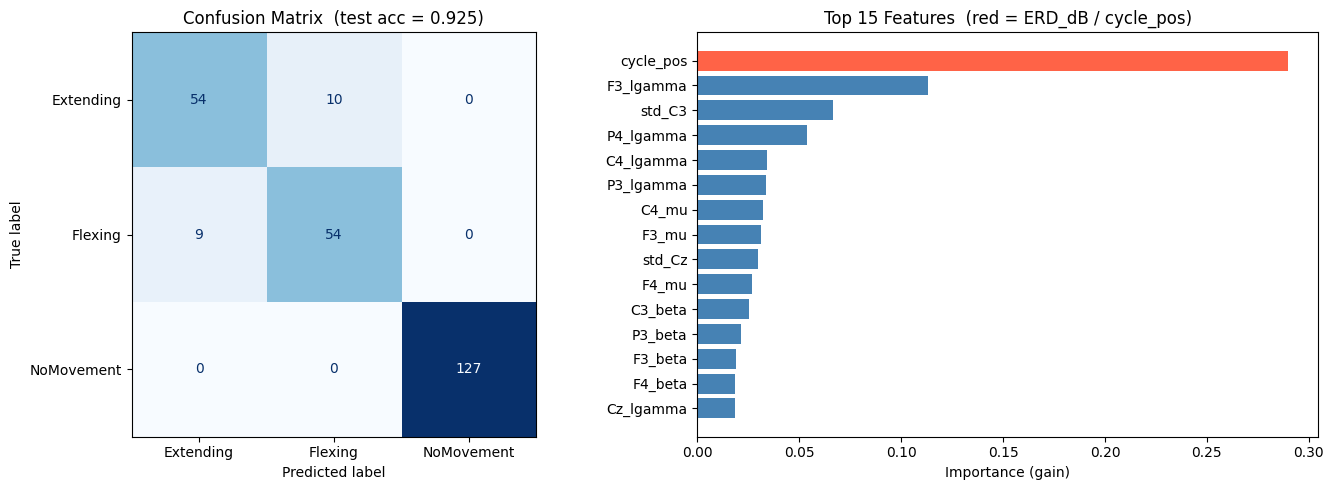

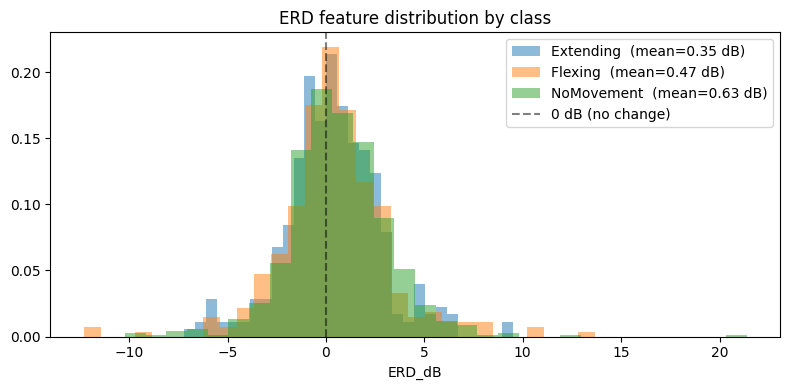

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix  (test acc = {test_acc:.3f})')

# ── Feature importance (top 15) ────────────────────────────────────────────────
# Red bars = the two new features (ERD_dB and cycle_pos) added in this notebook
importances = model.feature_importances_
top_idx     = np.argsort(importances)[-15:]
colors      = ['tomato' if FEATURE_NAMES[i] in ('ERD_dB', 'cycle_pos') else 'steelblue'
               for i in top_idx]
axes[1].barh([FEATURE_NAMES[i] for i in top_idx], importances[top_idx], color=colors)
axes[1].set_title('Top 15 Features  (red = ERD_dB / cycle_pos)')
axes[1].set_xlabel('Importance (gain)')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, '3class_evaluation.png'), dpi=120, bbox_inches='tight')
plt.show()

# ── ERD distribution by class (sanity check) ──────────────────────────────────
# If ERD is doing its job, NoMovement should cluster near 0 dB and
# Flexing/Extending should lean negative (desynchronisation during movement)
fig2, ax2 = plt.subplots(figsize=(8, 4))
for cls in le.classes_:
    erd_vals = X[y == cls, 28]
    ax2.hist(erd_vals, bins=30, alpha=0.5, label=f'{cls}  (mean={erd_vals.mean():.2f} dB)', density=True)
ax2.axvline(0, color='black', linestyle='--', alpha=0.5, label='0 dB (no change)')
ax2.set_xlabel('ERD_dB')
ax2.set_title('ERD feature distribution by class')
ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, '3class_erd_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## Step 8 — Save Model
Saves four files to `models/`. The live detector loads all four at startup.

In [ ]:
# ── File paths ─────────────────────────────────────────────────────────────────
model_path  = os.path.join(MODEL_SAVE_DIR, 'xgb_3class_model.pkl')
scaler_path = os.path.join(MODEL_SAVE_DIR, '3class_scaler.pkl')
le_path     = os.path.join(MODEL_SAVE_DIR, '3class_label_encoder.pkl')
meta_path   = os.path.join(MODEL_SAVE_DIR, '3class_metadata.json')

# ── Pickle the three objects ───────────────────────────────────────────────────
with open(model_path,  'wb') as f: pickle.dump(model,  f)
with open(scaler_path, 'wb') as f: pickle.dump(scaler, f)
with open(le_path,     'wb') as f: pickle.dump(le,     f)

# ── Save metadata so the live detector can verify it loaded the right model ────
metadata = {
    'algorithm':              'XGBoost',
    'training_sampling_rate': SAMPLING_RATE,
    'epoch_window':           list(EPOCH_WINDOW),
    'epoch_window_label':     'Full Execution — 0.0 to 3.0 s after PostureStart',
    'baseline_window':        list(BASELINE_WINDOW),
    'approach':               '3-class: NoMovement / Flexing / Extending',
    'n_features':             30,
    'feature_names':          FEATURE_NAMES,
    'features_description':   '28 freq + 1 ERD_dB + 1 cycle_pos_normalised',
    'n_samples':              int(X.shape[0]),
    'n_participants':         len(participants),
    'classes':                list(le.classes_),
    'label_map':              LABEL_MAP,
    'xgb_params':             XGB_PARAMS,
    'cv_accuracy_mean':       float(cv_scores.mean()),
    'cv_accuracy_std':        float(cv_scores.std()),
    'test_accuracy':          float(test_acc),
    'training_date':          datetime.datetime.now().isoformat(),
    'bandpass_hz':            list(BANDPASS_FREQ),
    'notch_hz':               NOTCH_FREQ,
    'freq_bands':             FREQ_BANDS,
    'channel_order':          ['F3', 'F4', 'C3', 'Cz', 'C4', 'P3', 'P4'],
    'ml_epoch_seconds':       float(EPOCH_WINDOW[1]),
    'erd_n_baseline_seconds': 1.0,
}
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

# ── Confirmation ───────────────────────────────────────────────────────────────
for path, name in [(model_path,'model'), (scaler_path,'scaler'),
                   (le_path,'label_encoder'), (meta_path,'metadata')]:
    print(f'  Saved {name:<16s}→  {path}')

print(f'\n  Algorithm   : XGBoost')
print(f'  CV accuracy : {cv_scores.mean()*100:.1f}%  ±  {cv_scores.std()*100:.1f}%')
print(f'  Test acc    : {test_acc*100:.1f}%  (chance = {100/3:.1f}%)')
print(f'\n  ✓ Ready — run live_3class_detector.py to use this model in real time.')